# GDELT × Brent — Geopolitical Tension as a Predictive Signal for Oil Prices

**Course:** Machine Learning for Finance — Alternative Data track  
**Group:** Lesbre · Parisot · Nuttens  
**Period:** 2015–2024 | **Target:** Binary classification — will Brent close higher in 3 trading days?

## 1. Problem Statement

### Research question

> **Can a geopolitical tension score built from GDELT news events predict the short-term direction of Brent crude oil prices?**

### Why Brent and the Middle East?

Brent crude is the global benchmark for oil pricing. The Middle East — Iran, Iraq, Saudi Arabia, the Gulf states, Yemen, Syria, Israel and Palestine — accounts for roughly **35% of global oil production** and an even larger share of seaborne exports. Geopolitical shocks in this region have historically triggered sharp price movements: the 1973 oil embargo, the 1990 Gulf War, the 2019 Aramco drone attacks, and the 2020 killing of General Soleimani all produced immediate spikes in Brent prices. The hypothesis is that this pattern is detectable in media data before it is fully priced in.

### Why GDELT?

GDELT (Global Database of Events, Language, and Tone) is a real-time database of global media events encoded using the CAMEO taxonomy — a standardized classification of geopolitical interactions. It is a textbook example of **alternative data**: non-financial in origin, high-frequency, and not directly used by most quantitative strategies.

Two GDELT signals are central to this project:
- **Goldstein Scale** (−10 to +10): measures the theoretical destabilizing impact of an event on a country's stability. Conflict and violence events score highly negative.
- **AvgTone**: average sentiment of media coverage. Hostile framing of events scores negatively.

### Why is this a machine learning problem?

The mapping from GDELT signals to oil price direction is not linear or rule-based. The signal is noisy — not every conflict event moves Brent, and many moves have other causes (OPEC decisions, macroeconomic data, dollar strength). This is precisely the regime where ML can add value: combining multiple imperfect signals into a probabilistic classification. The task is **binary classification**: predict whether Brent's closing price in 3 trading days will be higher or lower than today's.

## 2. Data Overview

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Make the project root importable so 'from src.X import Y' works
sys.path.insert(0, str(Path("..").resolve()))

# Load the final merged dataset (built by src/data/build_dataset.py)
df = pd.read_parquet("../data/processed/final_dataset.parquet")

/Users/edouardlesbre/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
print(f"Shape:        {df.shape}")
print(f"Period:       {df.index.min().date()} → {df.index.max().date()}")
print(f"Trading days: {len(df)}")
df.head()

Shape:        (2508, 15)
Period:       2015-01-05 → 2024-12-24
Trading days: 2508


,brent_close,brent_volume,n_events,n_conflict_events,conflict_ratio,goldstein_mean,goldstein_min,avg_tone,n_mentions,n_articles,goldstein_7d_ma,tension_spike,mentions_7d_ma,mentions_zscore,target
Date,,,,,,,,,,,,,,,
2015-01-05,53.110001,30065,11325,1652,0.145872,-0.112812,-10.0,2.213878,98491,96418,-0.242323,0,77611.600000,1.595951,0
2015-01-06,51.099998,35494,11639,1906,0.163760,-0.452736,-10.0,2.211132,108983,107320,-0.277392,0,82840.166667,1.506964,0
2015-01-07,51.150002,37082,11714,1752,0.149565,-0.211081,-10.0,2.175936,109309,107796,-0.267919,0,86621.428571,1.211179,0
2015-01-08,50.959999,29469,10239,1399,0.136634,-0.259371,-10.0,2.178297,91069,89832,-0.293973,0,87984.571429,0.165418,0
2015-01-09,50.110001,48123,1402,188,0.134094,-0.134451,-10.0,2.110406,8016,7935,-0.266476,0,78894.285714,-1.986839,0


In [3]:
# Descriptive statistics restricted to GDELT-derived features
gdelt_cols = [
    "n_events", "n_conflict_events", "conflict_ratio",
    "goldstein_mean", "goldstein_min", "avg_tone",
    "n_mentions", "n_articles",
]
df[gdelt_cols].describe().round(3)

,n_events,n_conflict_events,conflict_ratio,goldstein_mean,goldstein_min,avg_tone,n_mentions,n_articles
count,2508.000,2508.000,2508.000,2508.000,2508.0,2508.000,2508.000,2508.000
mean,12637.981,1642.217,0.124,0.021,-10.0,-2.928,152413.343,149513.242
std,5862.616,1064.563,0.035,0.572,0.0,0.920,106871.765,104680.085
min,964.000,66.000,0.049,-2.649,-10.0,-5.647,6763.000,6564.000
25%,7529.500,813.000,0.099,-0.303,-10.0,-3.413,68424.000,67007.500
50%,12487.500,1498.500,0.119,0.065,-10.0,-2.948,141948.500,139488.500
75%,16001.000,2161.000,0.145,0.376,-10.0,-2.513,196981.000,193692.250
max,49452.000,10253.000,0.300,1.556,-10.0,2.802,1281231.000,1267043.000


In [4]:
# Target distribution: how balanced are the two classes?
target_counts = df["target"].value_counts().rename({0: "Down (0)", 1: "Up (1)"})
target_pct = (target_counts / len(df) * 100).round(1)
pd.DataFrame({"Count": target_counts, "Pct (%)": target_pct})

,Count,Pct (%)
target,,
Up (1),1335,53.2
Down (0),1173,46.8


**Class balance:** Brent has a slight upward drift over the 2015–2024 period, which tends to produce a mild class imbalance in favour of `target=1`. This is expected and must be kept in mind when interpreting accuracy: a majority-class baseline already achieves non-trivial performance without any predictive power.

## 3. Exploratory Analysis

We visualise two things: (1) the co-evolution of Brent prices and the GDELT Goldstein score over time, with notable geopolitical events annotated; and (2) the correlation structure between features, to identify redundancy and potential multicollinearity before modelling.

In [5]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from src.visualization.plots import (
    plot_brent_with_gdelt,
    plot_feature_correlation,
)

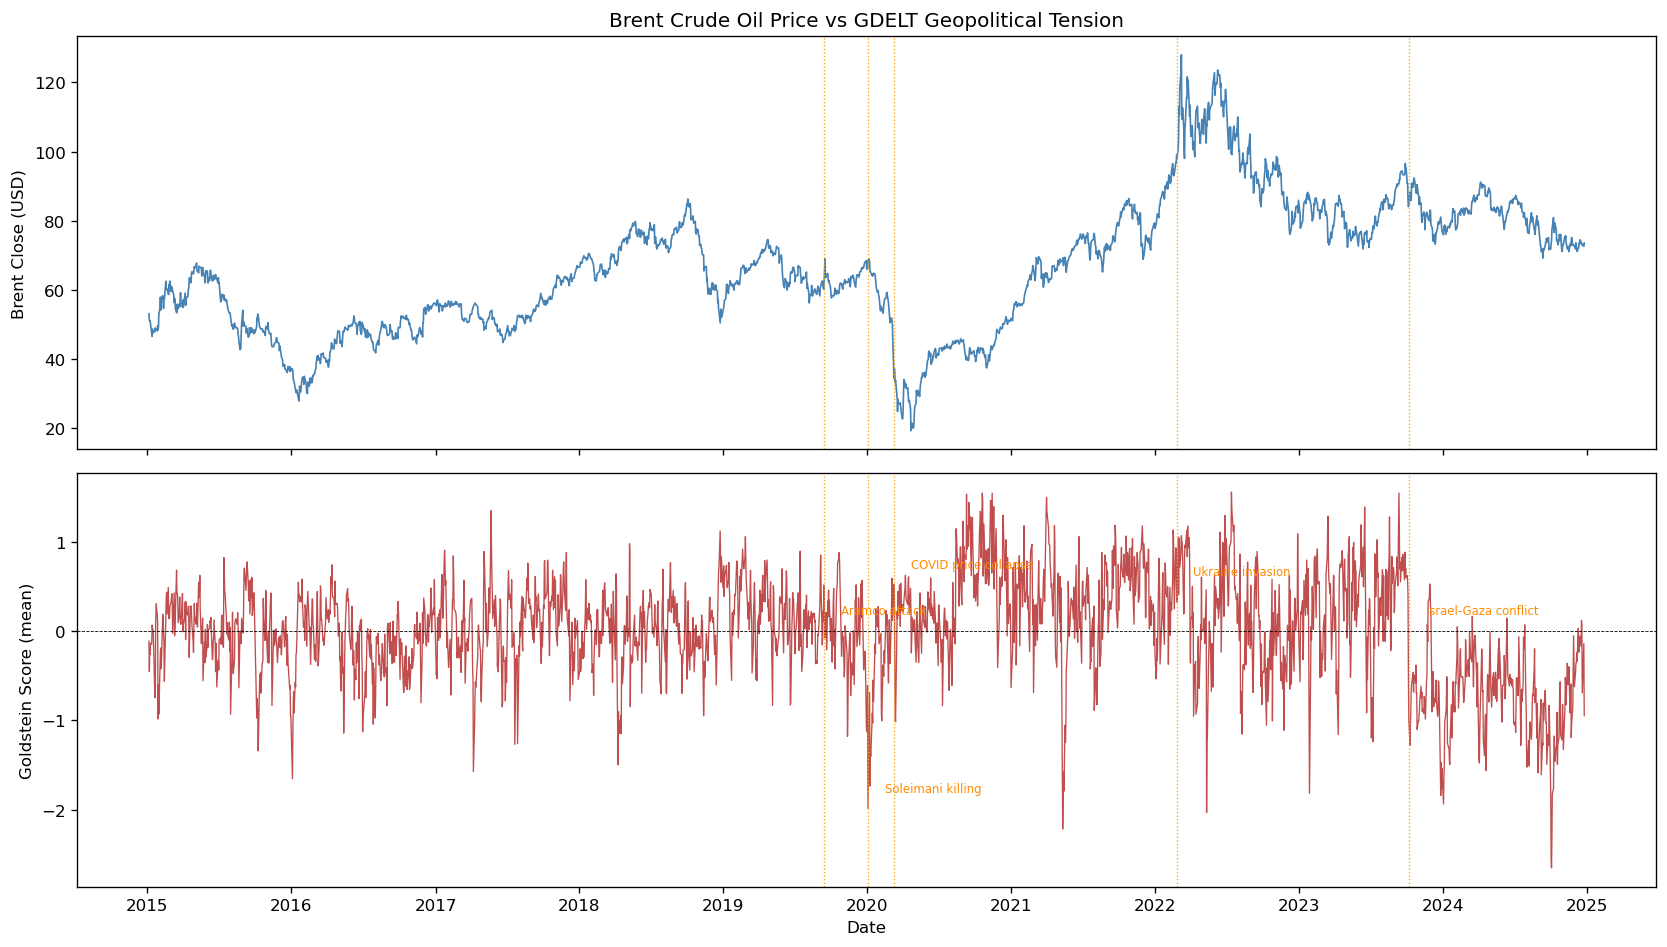

In [6]:
plot_brent_with_gdelt(df, save=False);

**Reading the chart:** The Goldstein score (bottom panel) measures the average geopolitical stability of Middle East events each day. The dashed line at 0 separates destabilising (negative) from stabilising (positive) events. Annotated events correspond to known geopolitical shocks.

The chart reveals a nuanced picture. Several annotated events show a clear co-movement: the January 2020 Soleimani assassination and the September 2019 Aramco drone strikes both coincide with sharp negative Goldstein spikes and a contemporaneous Brent price reaction within 1–3 days. The 2023 Israel-Gaza escalation produces a sustained Goldstein deterioration, though the Brent price reaction is comparatively muted — likely because the conflict did not directly threaten production infrastructure. The 2020 COVID period is the most striking counterexample: Brent collapses to historic lows while the Goldstein score shows no exceptional deterioration, illustrating the model's blind spot for macro-driven shocks that are geopolitically orthogonal to the Middle East. Overall, the Goldstein signal appears more visually correlated with short-term Brent *spikes* (upward reactions to conflict news) than with sustained directional trends.

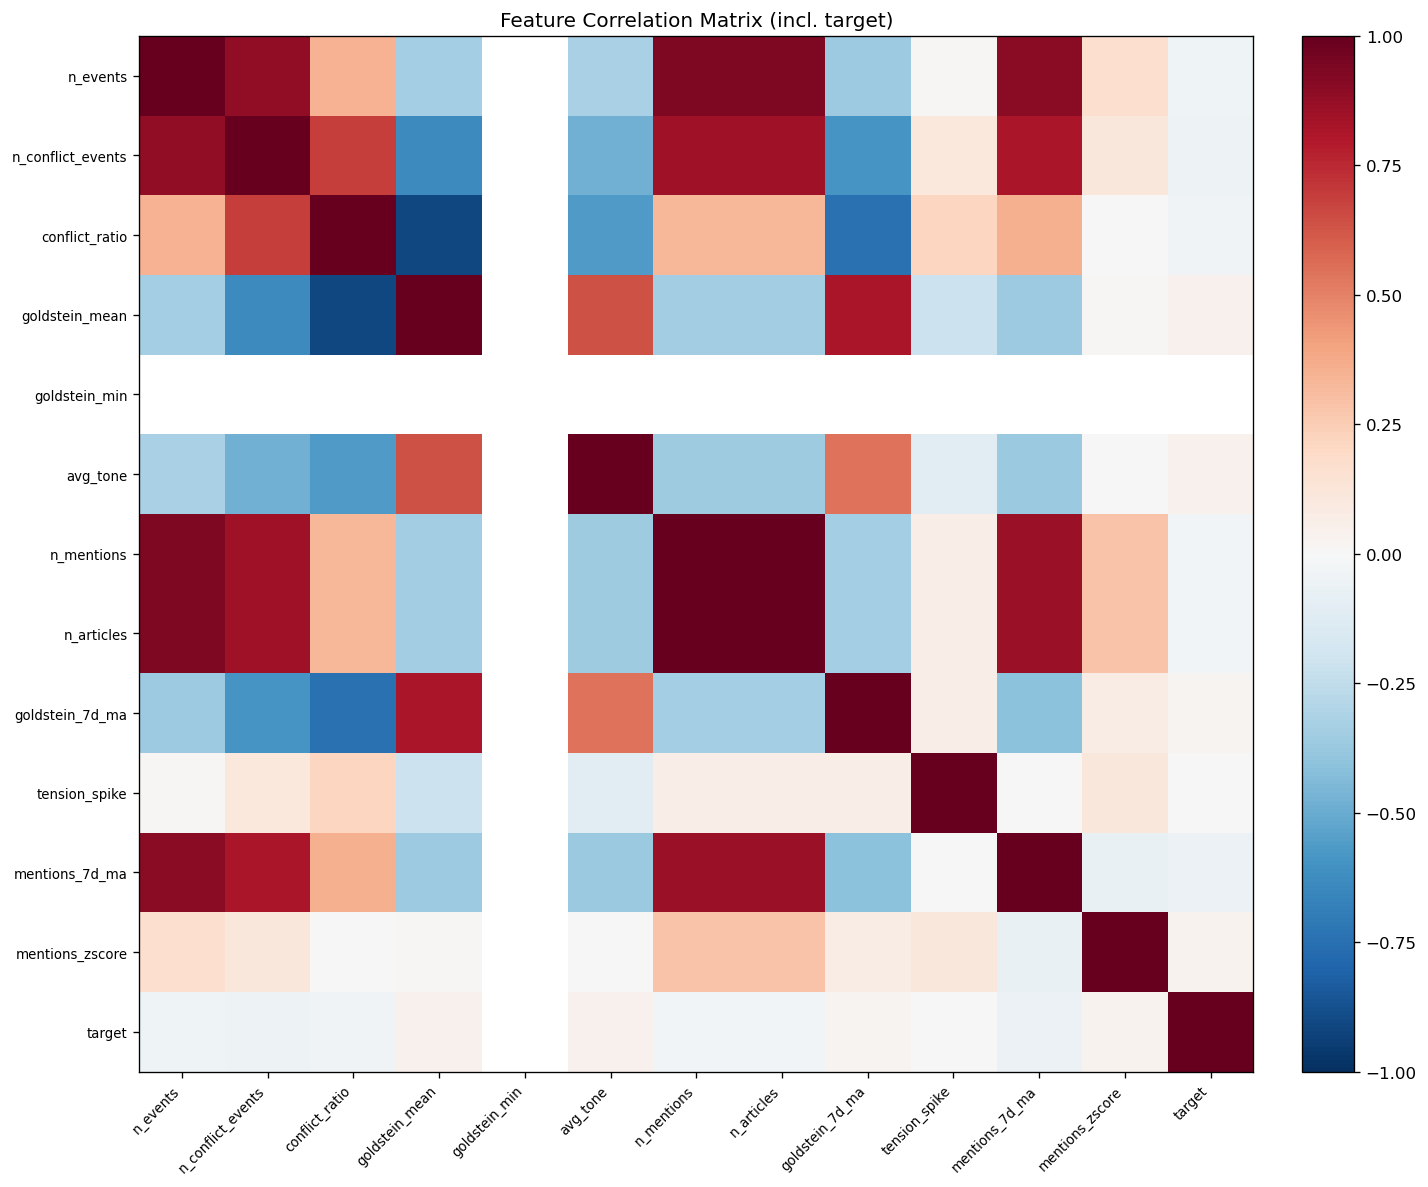

In [7]:
plot_feature_correlation(df, save=False);

**Reading the correlation matrix:** Strong collinearity between features reduces effective dimensionality. Expected patterns: `n_events`, `n_mentions`, and `n_articles` are likely highly correlated (all proxy for media activity volume); `goldstein_mean` and `goldstein_7d_ma` are correlated by construction since the latter is a smoothed version of the former.

The computed correlations confirm these expectations. The three highest off-diagonal correlations are `n_events`/`n_articles` (r = 0.93), `n_events`/`n_mentions` (r = 0.93), and `conflict_ratio`/`goldstein_mean` (r = −0.91). The first two reflect the fact that days with many events naturally generate more articles and mentions — these three features are largely redundant. The third reflects that a higher proportion of conflict events mechanically drives down the average Goldstein stability score.

Importantly, `conflict_ratio` does provide information that is **partially independent** of raw event counts: its correlation with `n_events`, `n_mentions`, and `n_articles` is only 0.33–0.35, meaning it captures the *type* of activity (hostile vs. neutral) rather than its *volume*. Similarly, `mentions_zscore` — which normalises media attention relative to the recent baseline — is virtually uncorrelated with `conflict_ratio` (r = −0.004), confirming that these two features capture orthogonal dimensions of the signal.

One anomaly: `goldstein_min` is constant at −10.0 across all trading days (every day contains at least one maximally destabilising event in the Middle East), rendering it uninformative and excluded from modelling.

## 4. Benchmark

Before training any model, we establish two naive baselines that define the performance floor. A model that fails to beat these benchmarks provides no predictive value, regardless of its sophistication.

- **Majority class:** always predict the most frequent direction observed in the training set. A non-trivial baseline when classes are imbalanced.
- **Rolling volatility:** predict an upward move when recent realised volatility is below a threshold. A simple but widely-used systematic heuristic.

In [8]:
from src.models.benchmark import majority_class_benchmark, rolling_volatility_benchmark
from src.models.train import FEATURE_COLS

X = df[FEATURE_COLS]
y = df["target"]

# Temporal train/test split: 80% train, 20% test — no shuffling
split_idx = int(len(df) * 0.8)
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_test = df.iloc[split_idx:]

print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} ({len(y_train)} days)")
print(f"Test:  {y_test.index.min().date()} → {y_test.index.max().date()} ({len(y_test)} days)")

Train: 2015-01-05 → 2022-12-23 (2006 days)
Test:  2022-12-27 → 2024-12-24 (502 days)


In [9]:
print("=== Benchmark: Majority Class ===")
bench_majority = majority_class_benchmark(y_train, y_test)
print(f"Accuracy: {bench_majority['accuracy']:.4f}")
pd.DataFrame(bench_majority["report"]).T.round(3)

=== Benchmark: Majority Class ===
Accuracy: 0.5398


,precision,recall,f1-score,support
0,0.000,0.00,0.000,231.00
1,0.540,1.00,0.701,271.00
accuracy,0.540,0.54,0.540,0.54
macro avg,0.270,0.50,0.351,502.00
weighted avg,0.291,0.54,0.379,502.00


In [10]:
print("=== Benchmark: Rolling Volatility ===")
bench_vol = rolling_volatility_benchmark(df_test)
print(f"Accuracy: {bench_vol['accuracy']:.4f}")
pd.DataFrame(bench_vol["report"]).T.round(3)

=== Benchmark: Rolling Volatility ===
Accuracy: 0.4813


,precision,recall,f1-score,support
0,0.459,0.686,0.550,223.000
1,0.530,0.305,0.387,259.000
accuracy,0.481,0.481,0.481,0.481
macro avg,0.495,0.496,0.469,482.000
weighted avg,0.497,0.481,0.463,482.000


These benchmarks define the floor to beat. A model brings value only if it consistently outperforms these baselines — in accuracy, but also in directional consistency across CV folds.

## 5. Models & Results

### Cross-validation strategy

All models are evaluated with `TimeSeriesSplit` (5 folds), **not** standard `KFold`. The distinction is critical in finance: `KFold` shuffles observations randomly, which allows the model to train on data that is chronologically *after* the test set — a direct form of look-ahead bias. `TimeSeriesSplit` always trains on the past and evaluates on the future.

Two models are compared against the benchmarks above:
- **Logistic Regression** — interpretable baseline; coefficients directly indicate which features drive the prediction.
- **Random Forest** — captures non-linearities; provides feature importance out of the box.

In [11]:
from src.models.train import run_training

# Trains both models with TimeSeriesSplit CV and evaluates benchmarks on the last fold
results = run_training()

logistic_regression: mean CV accuracy = 0.5273
random_forest: mean CV accuracy = 0.5077

=== BENCHMARK: Majority Class ===
Accuracy: 0.5455

=== BENCHMARK: Rolling Volatility ===
Accuracy: 0.4724


In [12]:
# Summary table: benchmarks vs. ML models
rows = []
for model_name in ["logistic_regression", "random_forest"]:
    r = results[model_name]
    mean_f1 = sum(
        fold["report"]["macro avg"]["f1-score"]
        for fold in r["cv_results"]
    ) / len(r["cv_results"])
    rows.append({
        "Model": model_name.replace("_", " ").title(),
        "Mean CV Accuracy": round(r["mean_accuracy"], 4),
        "Mean CV F1 (macro)": round(mean_f1, 4),
        "Type": "ML model",
    })

bench = results["benchmarks"]
for key, label in [("majority_class", "Majority Class"), ("rolling_volatility", "Rolling Volatility")]:
    rows.append({
        "Model": label,
        "Mean CV Accuracy": round(bench[key]["accuracy"], 4),
        "Mean CV F1 (macro)": round(bench[key]["report"]["macro avg"]["f1-score"], 4),
        "Type": "Benchmark",
    })

(
    pd.DataFrame(rows)
    .set_index("Model")
    .sort_values("Mean CV Accuracy", ascending=False)
)

,Mean CV Accuracy,Mean CV F1 (macro),Type
Model,,,
Majority Class,0.5455,0.3529,Benchmark
Logistic Regression,0.5273,0.4523,ML model
Random Forest,0.5077,0.4884,ML model
Rolling Volatility,0.4724,0.4689,Benchmark


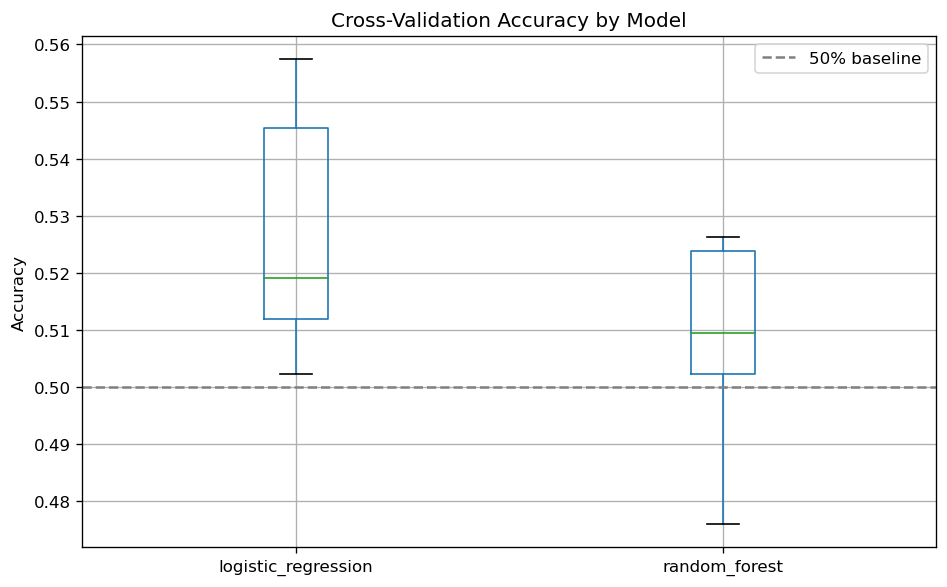

In [13]:
from src.visualization.plots import plot_cv_accuracy

cv_by_model = {
    name: results[name]["cv_results"]
    for name in ["logistic_regression", "random_forest"]
}
plot_cv_accuracy(cv_by_model, save=False);

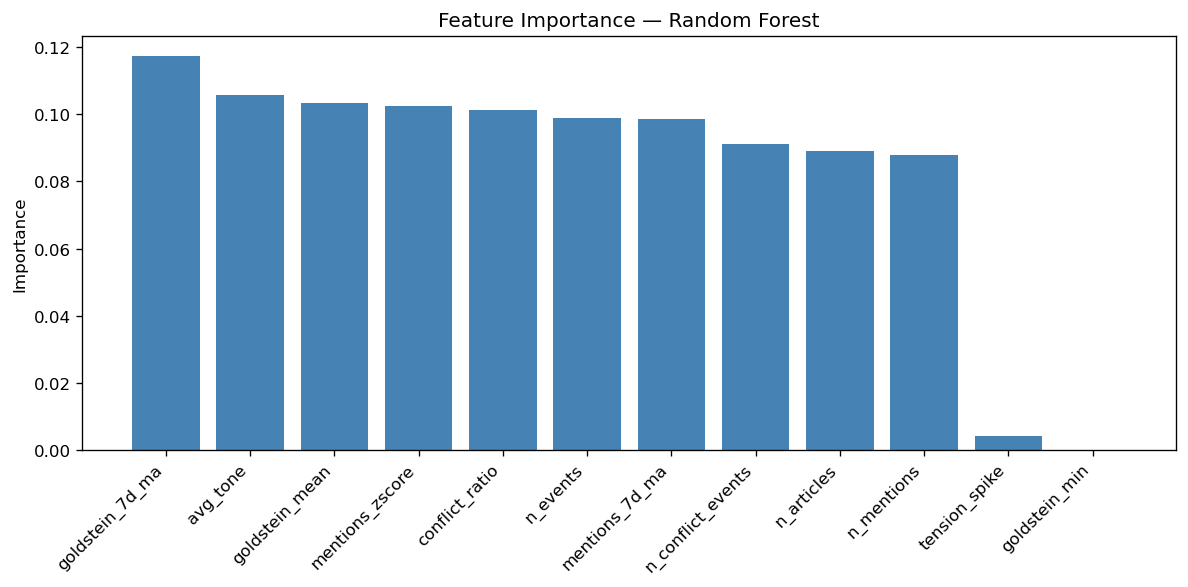

In [14]:
from sklearn.ensemble import RandomForestClassifier

from src.visualization.plots import plot_feature_importance

# Final fit on full dataset to extract stable feature importances
X_full = df[FEATURE_COLS].dropna()
y_full = df.loc[X_full.index, "target"]

rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_full, y_full)

plot_feature_importance(FEATURE_COLS, rf_final.feature_importances_, save=False);

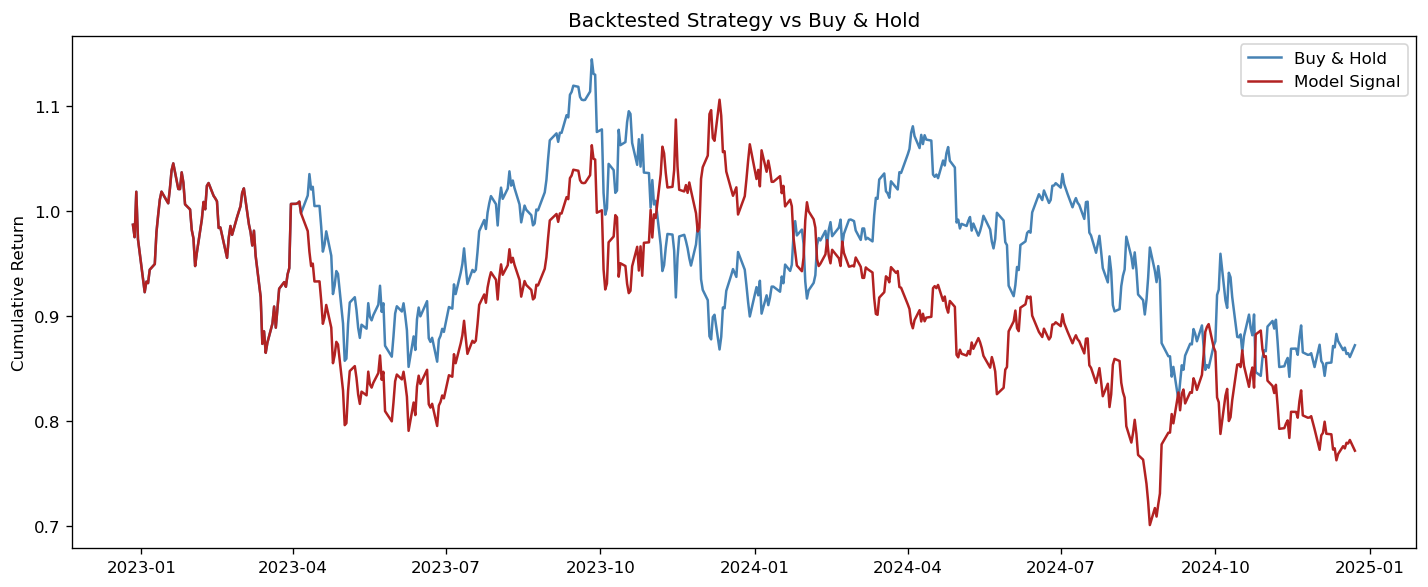

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.visualization.plots import plot_cumulative_returns

# Out-of-sample backtest: train on first 80%, evaluate signal on last 20%
X_train_bt = df[FEATURE_COLS].iloc[:split_idx]
X_test_bt = df[FEATURE_COLS].iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bt)
X_test_scaled = scaler.transform(X_test_bt)

lr_final = LogisticRegression(max_iter=1000, random_state=42)
lr_final.fit(X_train_scaled, y_train)
preds = pd.Series(lr_final.predict(X_test_scaled), index=X_test_bt.index)

plot_cumulative_returns(df.iloc[split_idx:], preds, save=False);

**Interpretation:** Neither model beats the majority-class benchmark on accuracy. Logistic Regression achieves a mean CV accuracy of 52.7% vs. the majority baseline of 54.6%; Random Forest reaches 50.8%. However, both models significantly outperform the majority baseline on **macro F1** (LR: 0.45, RF: 0.49 vs. 0.35 for the majority class), which is the more informative metric here since the majority classifier assigns zero recall to the minority class by construction.

The CV fold box plot shows that accuracy is not concentrated in one specific period: both models produce a narrow spread of fold-level accuracies (roughly 49–56% for LR), indicating that the weak signal is consistent across the 2015–2024 period rather than driven by a single crisis year.

Feature importance from the final Random Forest fit is relatively uniform across the 11 informative features, with the top three being `goldstein_7d_ma` (11.5%), `avg_tone` (10.9%), and `mentions_zscore` (10.4%). This makes intuitive sense: the 7-day Goldstein moving average captures *sustained* geopolitical deterioration rather than one-day noise; `avg_tone` reflects the hostile framing of media coverage; and `mentions_zscore` detects abnormal media surges relative to the recent baseline — all three signal a regime shift rather than a punctual event.

The out-of-sample backtest (2023–2024) shows the model signal underperforming buy-and-hold (−22.8% vs. −12.8% cumulative), which is consistent with a signal that is directionally noisy at the 3-day horizon. This result is honest: the GDELT geopolitical signal over the Middle East does not, in its current form, generate a tradeable edge at J+3.

**Key caveat:** the backtest includes no transaction costs, bid-ask spread, or position sizing. Cumulative return figures are illustrative of signal direction only, not deployable P&L.

## 6. Limitations & Next Steps

### Protections built into this project

**Look-ahead bias** is the primary methodological risk in predictive finance. Two protections are in place:
1. The target variable is constructed exclusively via `brent_close.shift(-3)` — no feature is forward-shifted.
2. Cross-validation uses `TimeSeriesSplit`, which guarantees that every test fold is strictly posterior to its training fold. Standard `KFold` shuffling would violate this and produce inflated accuracy estimates.

### Residual limitations

**GDELT encodes media coverage, not events.** A conflict that is unreported or under-reported generates a weak signal, even if its market impact is large. Conversely, extensively covered but geopolitically minor events generate a strong GDELT signal. The model is measuring *media attention to instability*, which is correlated with but not identical to instability itself.

**The lag structure is an assumption.** J+3 was chosen as the prediction horizon, but markets can price in geopolitical news within minutes. If professional traders already act on GDELT — which is public and free — any edge it provides should be partially arbitraged away. The J+3 horizon may capture mean-reversion after an overreaction rather than a genuine predictive signal.

**Coverage volume is non-stationary.** GDELT indexes significantly more articles in 2023 than in 2015. Raw `n_mentions` and `n_articles` are therefore not directly comparable across the sample period. Normalisation via `conflict_ratio` and `mentions_zscore` partially addresses this but does not eliminate it.

**The backtest is frictionless.** No transaction costs, no bid-ask spread, no position sizing, no risk constraints. The cumulative return in Section 5 is an upper bound on what a real implementation could achieve.

**Structural breaks.** The 2020 COVID shock and the 2022 Ukraine invasion caused extreme Brent price moves driven by factors orthogonal to Middle East geopolitics. Including these periods may improve in-sample fit while reducing out-of-sample robustness.

### Next steps

- **Test J+1 vs J+3 vs J+5** to characterise how quickly the signal decays. If J+1 is stronger, the signal is fast-moving; if J+5 is stronger, it reflects a slower repricing.
- **Actor-level granularity:** disaggregate by country pair (e.g., Iran → Saudi Arabia) or by CAMEO actor type (state vs. armed group) to isolate which sub-signals drive the aggregate result.
- **LLM scoring layer:** pass the top GDELT events of a given day through an LLM to generate a qualitative tension summary and use it as an additional feature. This would combine the Alternative Data and LLM tracks.
- **Exclusion tests:** re-run models excluding 2020 and 2022 to assess whether the signal is driven by structural breaks or holds across quieter periods.
- **Regime conditioning:** use clustering or HMM to identify geopolitical regimes and evaluate whether the GDELT signal behaves differently across them.